<a href="https://colab.research.google.com/github/Bhanusri2005/-DATA-ANALYSIS-WITH-COMPLEX-QUERIES/blob/main/Student_Performance_Analysis_Using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# ==========================================
# Student Performance Dashboard
# Author : Bhanu Sri
# Libraries : Pandas, NumPy, Matplotlib, Seaborn
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# Load Dataset
# ------------------------------------------

df = pd.read_csv("/content/student_data.csv")
df


,Unnamed: 0,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,0,female,NaN,bachelor's degree,standard,none,married,regularly,yes,3.0,school_bus,< 5,71,71,74
1,1,female,group C,some college,standard,NaN,married,sometimes,yes,0.0,NaN,5 - 10,69,90,88
2,2,female,group B,master's degree,standard,none,single,sometimes,yes,4.0,school_bus,< 5,87,93,91
3,3,male,group A,associate's degree,free/reduced,none,married,never,no,1.0,NaN,5 - 10,45,56,42
4,4,male,group C,some college,standard,none,married,sometimes,yes,0.0,school_bus,5 - 10,76,78,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30636,816,female,group D,high school,standard,none,single,sometimes,no,2.0,school_bus,5 - 10,59,61,65
30637,890,male,group E,high school,standard,none,single,regularly,no,1.0,private,5 - 10,58,53,51
30638,911,female,NaN,high school,free/reduced,completed,married,sometimes,no,1.0,private,5 - 10,61,70,67
30639,934,female,group D,associate's degree,standard,completed,married,regularly,no,3.0,school_bus,5 - 10,82,90,93


In [15]:

# ------------------------------------------
# Dataset Information
# ------------------------------------------

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

# ------------------------------------------
# Create Overall Score
# ------------------------------------------

df["OverallScore"] = (
    df["MathScore"] +
    df["ReadingScore"] +
    df["WritingScore"]
) / 3

# ------------------------------------------
# Average Scores by Gender
# ------------------------------------------

gender_scores = df.groupby("Gender")[
    ["MathScore", "ReadingScore", "WritingScore"]
].mean()

gender_scores["OverallScore"] = (
    gender_scores["MathScore"] +
    gender_scores["ReadingScore"] +
    gender_scores["WritingScore"]
) / 3

print("\nAverage Scores by Gender")
print(gender_scores)

# ------------------------------------------
# Highest Scoring Gender
# ------------------------------------------

print("\n===================================")
print("Highest Scoring Gender")
print("===================================")

print(
    "Math Score :",
    gender_scores["MathScore"].idxmax(),
    "(",
    round(gender_scores["MathScore"].max(), 2),
    ")",
)

print(
    "Reading Score :",
    gender_scores["ReadingScore"].idxmax(),
    "(",
    round(gender_scores["ReadingScore"].max(), 2),
    ")",
)

print(
    "Writing Score :",
    gender_scores["WritingScore"].idxmax(),
    "(",
    round(gender_scores["WritingScore"].max(), 2),
    ")",
)

print(
    "Overall Score :",
    gender_scores["OverallScore"].idxmax(),
    "(",
    round(gender_scores["OverallScore"].max(), 2),
    ")",
)





First 5 Rows
   Unnamed: 0  Gender EthnicGroup          ParentEduc     LunchType TestPrep  \
0           0  female         NaN   bachelor's degree      standard     none   
1           1  female     group C        some college      standard      NaN   
2           2  female     group B     master's degree      standard     none   
3           3    male     group A  associate's degree  free/reduced     none   
4           4    male     group C        some college      standard     none   

  ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings TransportMeans  \
0             married     regularly          yes         3.0     school_bus   
1             married     sometimes          yes         0.0            NaN   
2              single     sometimes          yes         4.0     school_bus   
3             married         never           no         1.0            NaN   
4             married     sometimes          yes         0.0     school_bus   

  WklyStudyHours  MathScore  R

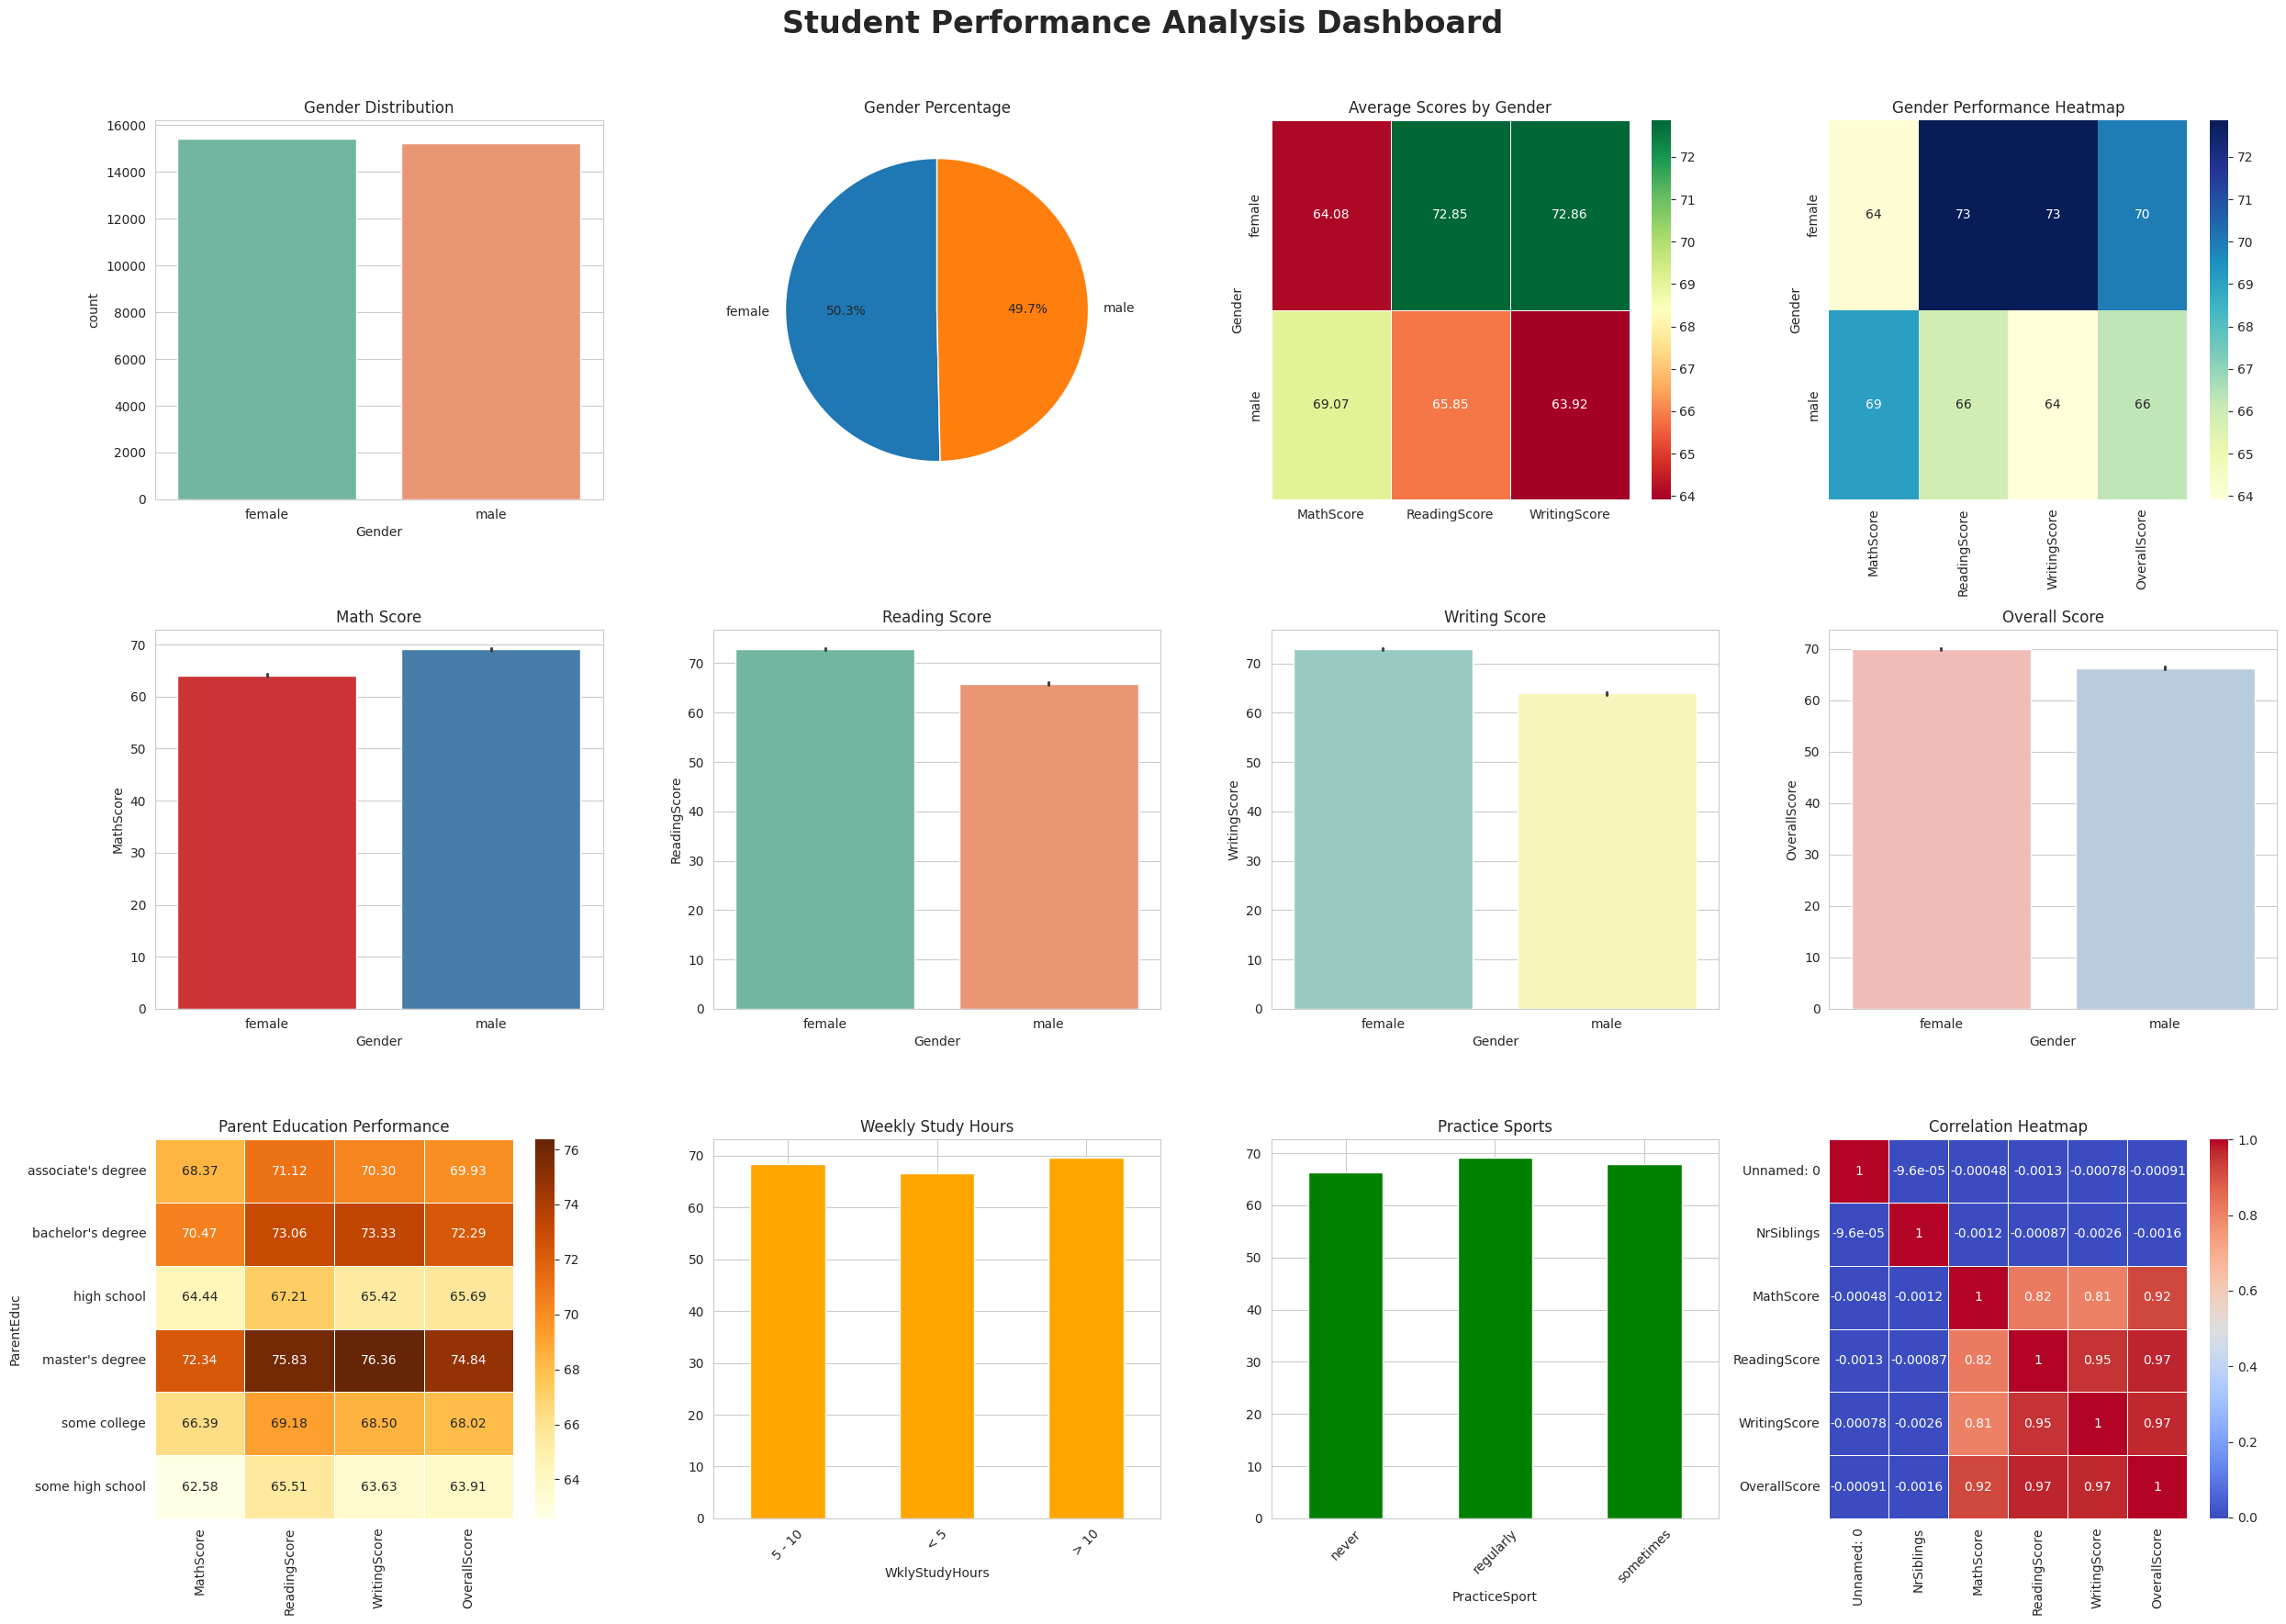

In [12]:
# ------------------------------------------
# Dashboard Style
# ------------------------------------------

sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 4, figsize=(25, 18))

fig.suptitle(
    "Student Performance Analysis Dashboard",
    fontsize=24,
    fontweight="bold",
)

# ==========================================================
# 1 Gender Count Plot
# ==========================================================

sns.countplot(
    data=df,
    x="Gender",
    hue="Gender",
    ax=axes[0, 0],
    palette="Set2",
    legend=False
)

axes[0, 0].set_title("Gender Distribution")

# ==========================================================
# 2 Gender Pie Chart
# ==========================================================

gender_count = df["Gender"].value_counts()

axes[0, 1].pie(
    gender_count,
    labels=gender_count.index,
    autopct="%1.1f%%",
    startangle=90,
)

axes[0, 1].set_title("Gender Percentage")

# ==========================================================
# 3 Average Scores by Gender (Heatmap)
# ==========================================================

sns.heatmap(
    gender_scores[
        ["MathScore", "ReadingScore", "WritingScore"]
    ],
    annot=True,
    cmap="RdYlGn",
    fmt=".2f",
    linewidths=0.5,
    ax=axes[0, 2]
)

axes[0, 2].set_title("Average Scores by Gender")

# ==========================================================
# 4 Heatmap (Gender Scores)
# ==========================================================

sns.heatmap(
    gender_scores,
    annot=True,
    cmap="YlGnBu",
    ax=axes[0, 3]
)

axes[0, 3].set_title("Gender Performance Heatmap")

# ==========================================================
# 5 Math Score Comparison
# ==========================================================

sns.barplot(
    data=df,
    x="Gender",
    y="MathScore",
    hue="Gender",
    palette="Set1",
    ax=axes[1, 0],
    legend=False
)

axes[1, 0].set_title("Math Score")

# ==========================================================
# 6 Reading Score Comparison
# ==========================================================

sns.barplot(
    data=df,
    x="Gender",
    y="ReadingScore",
    hue="Gender",
    palette="Set2",
    ax=axes[1, 1],
    legend=False
)

axes[1, 1].set_title("Reading Score")

# ==========================================================
# 7 Writing Score Comparison
# ==========================================================

sns.barplot(
    data=df,
    x="Gender",
    y="WritingScore",
    hue="Gender",
    palette="Set3",
    ax=axes[1, 2],
    legend=False
)

axes[1, 2].set_title("Writing Score")

# ==========================================================
# 8 Overall Score Comparison
# ==========================================================

sns.barplot(
    data=df,
    x="Gender",
    y="OverallScore",
    hue="Gender",
    palette="Pastel1",
    ax=axes[1, 3],
    legend=False
)

axes[1, 3].set_title("Overall Score")

# ==========================================================
# 9 Parent Education (Heatmap)
# ==========================================================

parent = df.groupby("ParentEduc")[
    ["MathScore", "ReadingScore", "WritingScore", "OverallScore"]
].mean()

sns.heatmap(
    parent,
    annot=True,
    cmap="YlOrBr",
    fmt=".2f",
    linewidths=0.5,
    ax=axes[2, 0]
)

axes[2, 0].set_title("Parent Education Performance")

# ==========================================================
# 10 Weekly Study Hours
# ==========================================================

study = df.groupby("WklyStudyHours")[
    "OverallScore"
].mean()

study.plot(
    kind="bar",
    color="orange",
    ax=axes[2, 1]
)

axes[2, 1].set_title("Weekly Study Hours")
axes[2, 1].tick_params(axis="x", rotation=45)

# ==========================================================
# 11 Practice Sports
# ==========================================================

sport = df.groupby("PracticeSport")[
    "OverallScore"
].mean()

sport.plot(
    kind="bar",
    color="green",
    ax=axes[2, 2]
)

axes[2, 2].set_title("Practice Sports")
axes[2, 2].tick_params(axis="x", rotation=45)

# ==========================================================
# 12 Correlation Heatmap
# ==========================================================

numeric = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    ax=axes[2, 3]
)

axes[2, 3].set_title("Correlation Heatmap")

# ------------------------------------------
# Dashboard Layout
# ------------------------------------------

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

In [13]:

# ------------------------------------------
# Final Insights
# ------------------------------------------

print("\n===================================")
print("PROJECT INSIGHTS")
print("===================================")

print("Highest Math Score Gender      :", gender_scores["MathScore"].idxmax())
print("Highest Reading Score Gender   :", gender_scores["ReadingScore"].idxmax())
print("Highest Writing Score Gender   :", gender_scores["WritingScore"].idxmax())
print("Highest Overall Score Gender   :", gender_scores["OverallScore"].idxmax())

print("\nAverage Scores")
print(gender_scores)


PROJECT INSIGHTS
Highest Math Score Gender      : male
Highest Reading Score Gender   : female
Highest Writing Score Gender   : female
Highest Overall Score Gender   : female

Average Scores
        MathScore  ReadingScore  WritingScore  OverallScore
Gender                                                     
female  64.080654     72.853216     72.856457     69.930109
male    69.069856     65.854571     63.920418     66.281615


In [16]:
plt.savefig("dashboard.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>